In [1]:
import pandas as pd
df = pd.read_csv("../data/fake_job_postings.csv")

print(df.shape)
df.head()

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [17]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [18]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df[col] = df[col].fillna("")

df["text"] = df[text_columns].agg(" ".join, axis=1)

df["text"].head()

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: text, dtype: object

In [19]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

df["clean_text"].head()

0    marketing intern we re food and we ve created ...
1    customer service cloud video production second...
2    commissioning machinery assistant cma valor se...
3    account executive washington dc our passion fo...
4    bill review manager spotsource solutions llc i...
Name: clean_text, dtype: object

In [20]:
df["text_length"] = df["clean_text"].apply(len)
df["exclamation_count"] = df["text"].str.count("!")
df["has_company_logo"] = df["has_company_logo"].fillna(0)

In [21]:
df[["text_length", "exclamation_count", "has_company_logo"]].head()

,text_length,exclamation_count,has_company_logo
0,2594,1,1
1,5743,5,1
2,2612,0,1
3,5370,0,1
4,3746,0,1


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text = vectorizer.fit_transform(df["clean_text"])

X_text.shape

(17880, 5000)

In [15]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'text', 'clean_text', 'text_length', 'exclamation_count'],
      dtype='object')

In [41]:
from sklearn.preprocessing import StandardScaler

# Select structured columns
structured_cols = [
    "text_length",
    "exclamation_count",
    "has_company_logo",
    "high_risk_score",
    "medium_risk_score",
    "legitimacy_score",
    "risk_signal"
]

# Scale structured features
scaler = StandardScaler()
structured_features_scaled = scaler.fit_transform(df[structured_cols])

# Stack with TF-IDF
X = hstack([X_text, structured_features_scaled])

In [63]:
X = hstack([X_text, structured_features_scaled])

In [68]:
from scipy.sparse import csr_matrix

X = csr_matrix(X)

In [69]:
print(type(X))
print(X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(17880, 5007)


In [70]:
from sklearn.model_selection import train_test_split

y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [72]:
model_lr = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000
)

In [73]:
model_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [75]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model_lr.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3403
           1       0.54      0.90      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.93      0.83      3576
weighted avg       0.97      0.96      0.96      3576

ROC-AUC: 0.9894958375727638


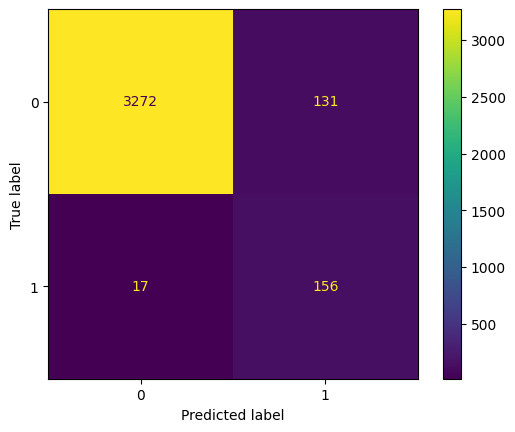

array([[3272,  131],
       [  17,  156]])

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format="d")
plt.show()

cm

In [77]:
import numpy as np
from sklearn.metrics import precision_recall_curve

probs = model_lr.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Find threshold where recall is ~0.90 (or whatever you prefer)
target_recall = 0.90
idx = np.argmin(np.abs(recall - target_recall))
best_threshold = thresholds[max(idx-1, 0)]

best_threshold, precision[idx], recall[idx]

(np.float64(0.4801295918187623),
 np.float64(0.5182724252491694),
 np.float64(0.9017341040462428))

In [79]:
y_pred_thresh = (probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3403
           1       0.52      0.91      0.66       173

    accuracy                           0.95      3576
   macro avg       0.76      0.93      0.82      3576
weighted avg       0.97      0.95      0.96      3576



In [81]:
from sklearn.metrics import average_precision_score
print("PR-AUC (Average Precision):", average_precision_score(y_test, probs))

PR-AUC (Average Precision): 0.8802667542482485


In [82]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

X_train_text = df.loc[X_train.indices if hasattr(X_train, "indices") else df.index, "clean_text"]

In [83]:
from sklearn.model_selection import train_test_split

X_raw = df["clean_text"]
y = df["fraudulent"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

pipe.fit(X_train_raw, y_train)

probs = pipe.predict_proba(X_test_raw)[:,1]
print("PR-AUC:", average_precision_score(y_test, probs))
print(classification_report(y_test, pipe.predict(X_test_raw)))

PR-AUC: 0.8907925278152141
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3403
           1       0.65      0.90      0.76       173

    accuracy                           0.97      3576
   macro avg       0.82      0.94      0.87      3576
weighted avg       0.98      0.97      0.97      3576



In [84]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(pipe, f)

In [85]:
import sys
import os

# Get project root (one level up from notebooks)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add src folder to path
sys.path.append(os.path.join(project_root, "src"))

from model import evaluate_thresholds

In [86]:
evaluate_thresholds(pipe, X_test_raw, y_test)


Threshold: 0.3
Confusion Matrix:
[[3127  276]
 [  11  162]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      3403
           1       0.37      0.94      0.53       173

    accuracy                           0.92      3576
   macro avg       0.68      0.93      0.74      3576
weighted avg       0.97      0.92      0.94      3576


Threshold: 0.4
Confusion Matrix:
[[3242  161]
 [  15  158]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      3403
           1       0.50      0.91      0.64       173

    accuracy                           0.95      3576
   macro avg       0.75      0.93      0.81      3576
weighted avg       0.97      0.95      0.96      3576


Threshold: 0.5
Confusion Matrix:
[[3320   83]
 [  17  156]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98   

In [87]:
from sklearn.metrics import f1_score
import numpy as np

probs = pipe.predict_proba(X_test_raw)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.6714285714285715
Best F1: 0.8313953488372093


In [88]:
high_risk_keywords = [
    "wire transfer", "processing fee", "registration fee", "training fee",
    "investment required", "deposit required", "money mule", "payment agent",
    "receive and forward", "bitcoin", "crypto", "usdt", "ethereum",
    "gift cards", "prepaid cards", "urgent hiring", "start today",
    "limited time", "no interview required", "easy money",
    "guaranteed income", "passive income", "whatsapp only",
    "telegram only", "contact via telegram", "direct message only"
]

medium_risk_keywords = [
    "data entry remote", "personal assistant remote", "mystery shopper",
    "package handling", "shipping from home",
    "commission only", "remote opportunity", "flexible opportunity",
    "online opportunity"
]

legitimate_keywords = [
    "salary range", "health insurance", "benefits package",
    "401k", "paid time off", "pension", "visa sponsorship",
    "bachelor", "master", "phd", "experience required",
    "technical stack", "python", "java", "sql",
    "team collaboration", "company website"
]

In [89]:
def count_keywords(text, keywords):
    return sum(keyword in text for keyword in keywords)

df["high_risk_score"] = df["clean_text"].apply(lambda x: count_keywords(x, high_risk_keywords))
df["medium_risk_score"] = df["clean_text"].apply(lambda x: count_keywords(x, medium_risk_keywords))
df["legitimacy_score"] = df["clean_text"].apply(lambda x: count_keywords(x, legitimate_keywords))

In [90]:
df["risk_signal"] = (
    df["high_risk_score"] * 3 +
    df["medium_risk_score"] * 1 -
    df["legitimacy_score"] * 2
)

In [91]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'text', 'clean_text', 'text_length', 'exclamation_count',
       'high_risk_score', 'medium_risk_score', 'legitimacy_score',
       'risk_signal'],
      dtype='object')